In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
response = requests.get("https://www.propertyfinder.ae/en/search?c=1&t=1&fu=0&ob=mr&page=1")
response.status_code

In [ ]:
properties=[]
for i in range (1,81):
    url = "https://www.propertyfinder.ae/en/search?c=1&t=1&fu=0&ob=mr&page="+str(i)
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    table = soup.find_all("section", class_="styles-module_content__G8JoH styles-module_property-card__content__TukJS")
    
    property_listing=[]
    
    for data in table:
        
        price = data.find("div", class_="styles-module_content__price-area__67RFS").text.strip()
    
        address = data.find("p", class_="styles-module_content__location__yBL3r").text.strip()
        
        element = data.find_all("p", class_="styles-module_content__details-item__1zBGw")
        
        bedroom = element[0].text.strip()
        
        bathroom = element[1].text.strip()

        area = element[2].text.strip()
            
        highlight = data.find("h3",class_="styles-module_content__title__pLLTh").text.strip()
        
        listing_property={'price':price, 'address':address, 'bedroom':bedroom, 'bathroom':bathroom, 'area':area, 'highlight':highlight}
        
        properties.append(listing_property)

In [ ]:
df = pd.DataFrame(properties)
df.to_csv("property_listing.csv", encoding='utf-8', index=False)

In [62]:
df = pd.read_csv("property_listing.csv")
df.head()

,price,address,bedroom,bathroom,area,highlight
0,"490,000 AED","Azizi Milan 20, City of Arabia, Dubai",studio,1,355 sqft,10%DP | LAGOON VIEW | 15%ROI | 1%MONTHLY | 3Y ...
1,"780,000 AED","Al Yasmeen 1, Al Yasmeen, Ajman",2,3,"1,590 sqft","Lowest down payment, flexible payment plan"
2,"555,000 AED","Garden Residences, Emirates City, Ajman",1,2,"1,192 sqft","Gym Parken swimming pool, modern design"
3,"685,117 AED","Ajman One - Phase 2, Ajman Downtown, Ajman",1,2,"1,200 sqft",Own your unit in Ajman&#39;s remaining projects
4,"1,399,966 AED","Azure By Lapis, RAK Central, Ras Al Khaimah",studio,1,700 sqft,Waterfront Elegance | High ROI | Premium Studio


In [63]:
df.shape

(1199, 6)

# DATA CLEANING ANG PREPROCESSING

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199 entries, 0 to 1198
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   price      1199 non-null   object
 1   address    1199 non-null   object
 2   bedroom    1199 non-null   object
 3   bathroom   1199 non-null   int64 
 4   area       1199 non-null   object
 5   highlight  1199 non-null   object
dtypes: int64(1), object(5)
memory usage: 56.3+ KB


#### CHECKING FOR NULL RECORDS

In [65]:
df.isnull().sum()

price        0
address      0
bedroom      0
bathroom     0
area         0
highlight    0
dtype: int64

#### CHECKING FOR DUPLICATES

In [66]:
df.duplicated().sum()

np.int64(25)

#### DROPPING DUPLICATE RECORDS

In [67]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [68]:
df.shape

(1174, 6)

# FEATURE ENGINEERING

#### FIXING INCONSISTENT FORMATS

In [69]:
df["price"] = df["price"].str.replace(r'[AED,]','',regex=True)
df["area"] = df["area"].str.replace(r'[sqft,]','',regex=True)
df = df.rename(columns = {"price":"price(AED)", "area":"area(sqft)"})
df["bedroom"] = df["bedroom"].str.replace('studio','0')

In [70]:
df.head()

,price(AED),address,bedroom,bathroom,area(sqft),highlight
0,490000,"Azizi Milan 20, City of Arabia, Dubai",0,1,355,10%DP | LAGOON VIEW | 15%ROI | 1%MONTHLY | 3Y ...
1,780000,"Al Yasmeen 1, Al Yasmeen, Ajman",2,3,1590,"Lowest down payment, flexible payment plan"
2,555000,"Garden Residences, Emirates City, Ajman",1,2,1192,"Gym Parken swimming pool, modern design"
3,685117,"Ajman One - Phase 2, Ajman Downtown, Ajman",1,2,1200,Own your unit in Ajman&#39;s remaining projects
4,1399966,"Azure By Lapis, RAK Central, Ras Al Khaimah",0,1,700,Waterfront Elegance | High ROI | Premium Studio


#### VALIDATING DATATYPES FOR COLUMNS

In [71]:
df['price(AED)'] = pd.to_numeric(df['price(AED)'],errors='coerce')
df['bedroom'] = pd.to_numeric(df['bedroom'])
df['area(sqft)'] = pd.to_numeric(df['area(sqft)'])
df['bathroom'] = pd.to_numeric(df['bathroom'])

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1174 entries, 0 to 1198
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price(AED)  1173 non-null   float64
 1   address     1174 non-null   object 
 2   bedroom     1174 non-null   int64  
 3   bathroom    1174 non-null   int64  
 4   area(sqft)  1174 non-null   int64  
 5   highlight   1174 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 64.2+ KB


#### HANDLING NULL VALUES

In [73]:
df = df.dropna(subset="price(AED)")
df['price(AED)'] = df['price(AED)'].astype('int64')

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1173 entries, 0 to 1198
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   price(AED)  1173 non-null   int64 
 1   address     1173 non-null   object
 2   bedroom     1173 non-null   int64 
 3   bathroom    1173 non-null   int64 
 4   area(sqft)  1173 non-null   int64 
 5   highlight   1173 non-null   object
dtypes: int64(4), object(2)
memory usage: 64.1+ KB


#### CREATING NEW FEATURES

In [75]:
df["price_per_sqft"] = (df["price(AED)"] / df["area(sqft)"]).round(2)
df["location"] = df["address"].str.split(',').str[-1].str.strip()
df["property_type"] = df["bedroom"].apply(lambda x: "studio" if x == 0 else"flat" if 1 <= x <=2 else"house" if 3<= x <=4 else "villa")

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1173 entries, 0 to 1198
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price(AED)      1173 non-null   int64  
 1   address         1173 non-null   object 
 2   bedroom         1173 non-null   int64  
 3   bathroom        1173 non-null   int64  
 4   area(sqft)      1173 non-null   int64  
 5   highlight       1173 non-null   object 
 6   price_per_sqft  1173 non-null   float64
 7   location        1173 non-null   object 
 8   property_type   1173 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 91.6+ KB


In [77]:
df.isna().sum()

price(AED)        0
address           0
bedroom           0
bathroom          0
area(sqft)        0
highlight         0
price_per_sqft    0
location          0
property_type     0
dtype: int64

# Exploratory Data Analysis (EDA)

In [78]:
df.head()

,price(AED),address,bedroom,bathroom,area(sqft),highlight,price_per_sqft,location,property_type
0,490000,"Azizi Milan 20, City of Arabia, Dubai",0,1,355,10%DP | LAGOON VIEW | 15%ROI | 1%MONTHLY | 3Y ...,1380.28,Dubai,studio
1,780000,"Al Yasmeen 1, Al Yasmeen, Ajman",2,3,1590,"Lowest down payment, flexible payment plan",490.57,Ajman,flat
2,555000,"Garden Residences, Emirates City, Ajman",1,2,1192,"Gym Parken swimming pool, modern design",465.60,Ajman,flat
3,685117,"Ajman One - Phase 2, Ajman Downtown, Ajman",1,2,1200,Own your unit in Ajman&#39;s remaining projects,570.93,Ajman,flat
4,1399966,"Azure By Lapis, RAK Central, Ras Al Khaimah",0,1,700,Waterfront Elegance | High ROI | Premium Studio,1999.95,Ras Al Khaimah,studio


In [79]:
df.describe()

,price(AED),bedroom,bathroom,area(sqft),price_per_sqft
count,1.173000e+03,1173.000000,1173.000000,1173.000000,1173.000000
mean,3.175860e+06,1.407502,2.146633,1381.123615,2482.308133
std,2.043831e+07,0.955143,0.998625,4720.654721,18003.953614
min,1.000000e+05,0.000000,1.000000,75.000000,4.620000
25%,9.150000e+05,1.000000,1.000000,719.000000,1159.600000
50%,1.523627e+06,1.000000,2.000000,984.000000,1686.420000
75%,2.500000e+06,2.000000,3.000000,1416.000000,2395.580000
max,6.720490e+08,5.000000,6.000000,115386.000000,616558.680000


In [80]:
avg_price_by_location = df.groupby('location')['price(AED)'].mean().round(0).astype(int)

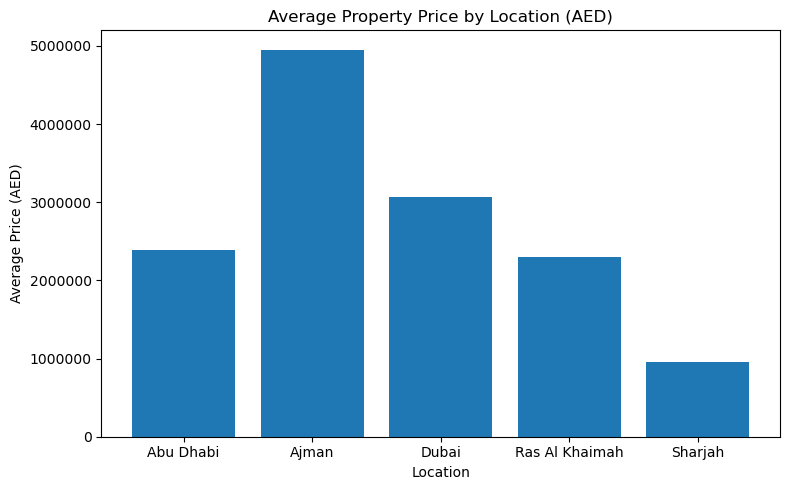

In [81]:
plt.figure(figsize=(8,5))
plt.bar(avg_price_by_location.index,avg_price_by_location.values)
plt.title('Average Property Price by Location (AED)')
plt.xlabel('Location')
plt.ylabel('Average Price (AED)')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

#### HANDLING OUTLIERS 

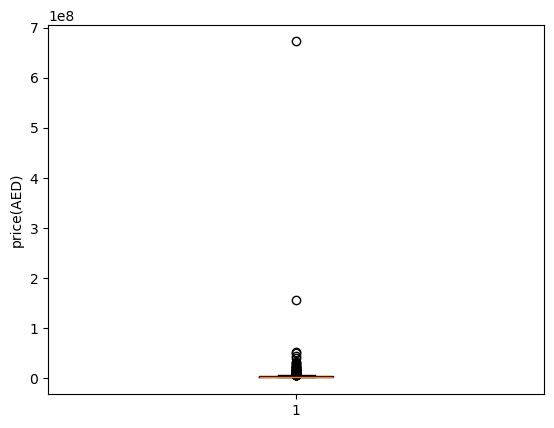

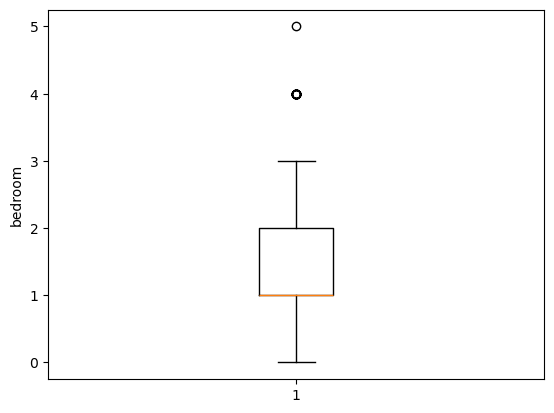

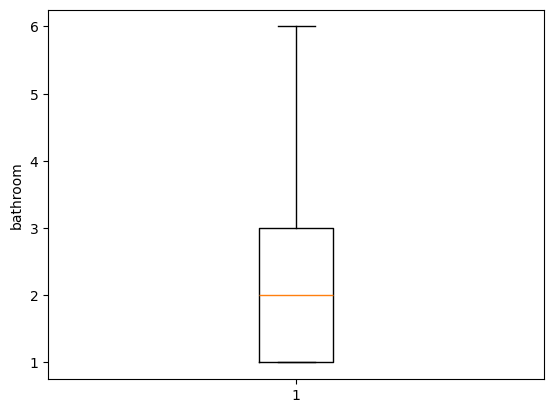

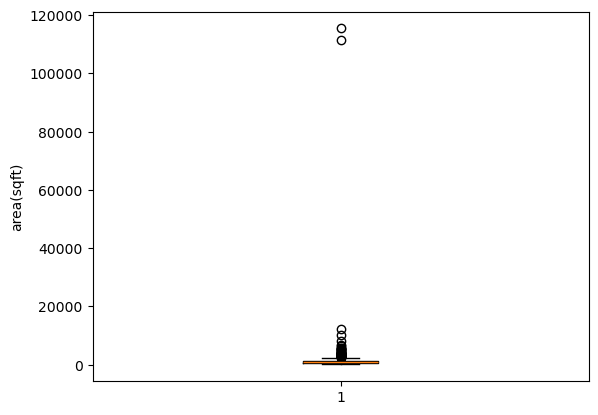

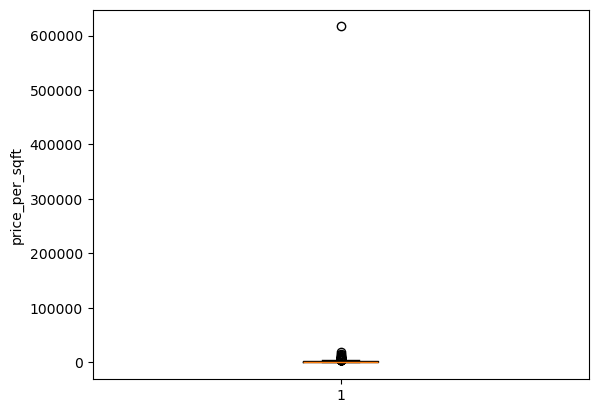

In [82]:
num_cols = df.select_dtypes(include="number").columns
for i in num_cols:
    plt.figure()
    plt.boxplot(df[i])
    plt.ylabel(i)
    plt.show()

#### USING IQR CAPPING METHOD TO HANDLE OUTLIERS FOR INDEPENDENT VARIABLES

In [83]:
def outliers(cap):
    Q1 = cap.quantile(0.25)
    Q3 = cap.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    return cap.clip(lower_bound,upper_bound)
outlier_cols = ['area(sqft)','bedroom','price_per_sqft']
for i in outlier_cols:
    df[i] = outliers(df[i])
    

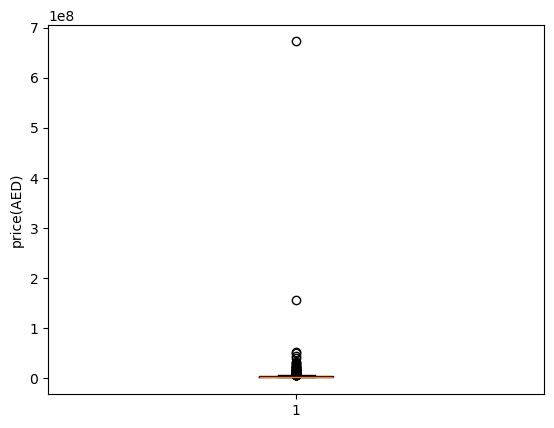

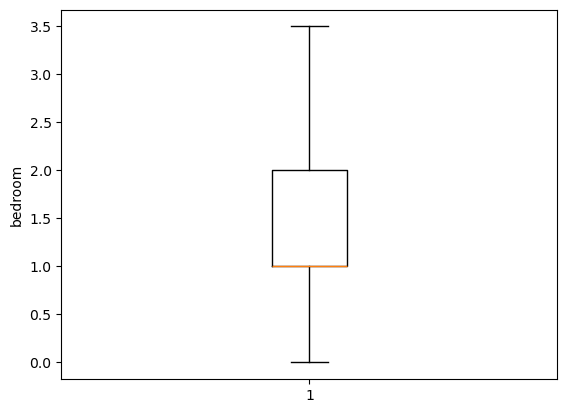

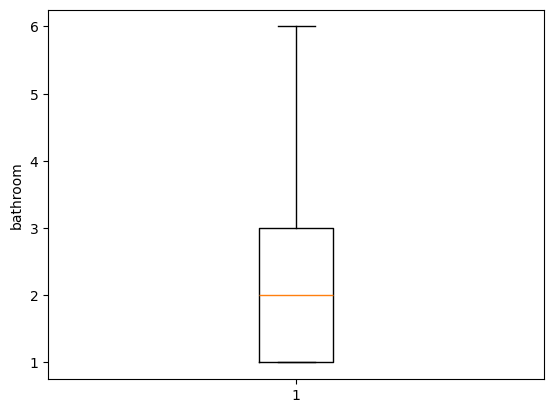

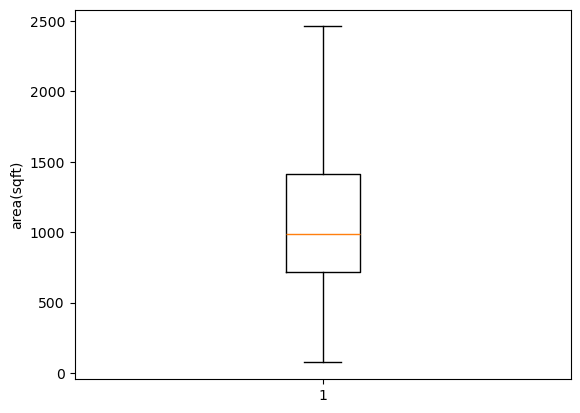

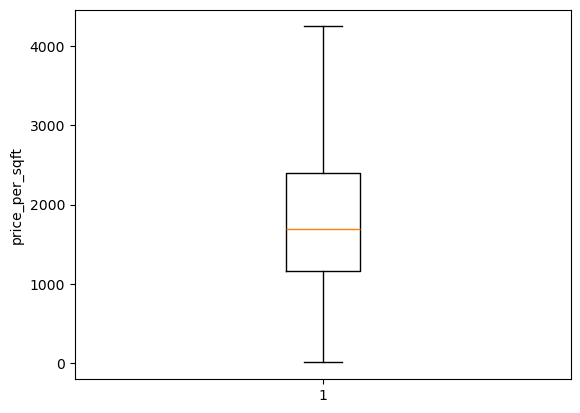

In [84]:
num_cols = df.select_dtypes(include="number").columns
for i in num_cols:
    plt.figure()
    plt.boxplot(df[i])
    plt.ylabel(i)
    plt.show()

#### Now all independent variables has no outliers

In [86]:
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include="object").columns
for e in cat_cols:
    df[e]= LabelEncoder().fit_transform(df[e])

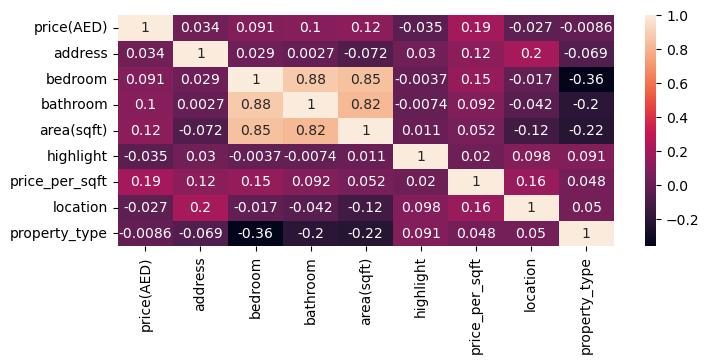

In [87]:
num_df = df.select_dtypes(include="number")
corr = num_df.corr()
plt.figure(figsize=(8,3))
sns.heatmap(corr, annot=True)
plt.show()

In [88]:
lower = df['price(AED)'].quantile(0.01)
upper = df['price(AED)'].quantile(0.99)
df['price(AED)'] = np.clip(df['price(AED)'], lower, upper)

In [89]:
df['price(AED)'].describe()

count    1.173000e+03
mean     2.396982e+06
std      3.146812e+06
min      2.214400e+05
25%      9.150000e+05
50%      1.523627e+06
75%      2.500000e+06
max      2.152780e+07
Name: price(AED), dtype: float64

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1173 entries, 0 to 1198
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price(AED)      1173 non-null   float64
 1   address         1173 non-null   int64  
 2   bedroom         1173 non-null   float64
 3   bathroom        1173 non-null   int64  
 4   area(sqft)      1173 non-null   float64
 5   highlight       1173 non-null   int64  
 6   price_per_sqft  1173 non-null   float64
 7   location        1173 non-null   int64  
 8   property_type   1173 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 91.6 KB


## MACHINE LEARNING MODEL

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

x = df[['area(sqft)', 'price_per_sqft', 'location', 'property_type']]
df['logprice'] = np.log1p(df['price(AED)'])
y = df['logprice']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)


y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)


y_train_actual_price = np.expm1(y_train)
y_test_actual_price = np.expm1(y_test)

y_train_pred_price = np.expm1(y_train_pred)
y_test_pred_price = np.expm1(y_test_pred)


print(f"R-square value for training data : {r2_score(y_train, y_train_pred):.2f}")
print(f"R-square value for testing data  : {r2_score(y_test, y_test_pred):.2f}")

print(f"RMSE value for training data : {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"RMSE value for testing data : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")


R-square value for training data : 0.91
R-square value for testing data  : 0.91
RMSE value for training data : 0.26
RMSE value for testing data : 0.23
